# Otimização Trans-Dataset (Fujita $\rightarrow$ Mathys) via Atenção Cosseno e Protótipos Consolidados

Este experimento avalia empiricamente as melhorias propostas no **ADR 010** e **ADR 011**, com foco na superação dos desafios técnicos da imputação trans-dataset entre estudos clínicos de RNA-seq de célula única diferentes:
1. **Atenção Normalizada por Cosseno (`normalize=True`):** Supressão do viés de esparsidade e profundidade transcricional (*Sparsity Bias*) no cálculo do produto escalar da rede Hopfield.
2. **Desacoplamento de Subespaço (`subspace_mask`):** Separação do cálculo da atenção no subespaço compartilhado para evitar inflação de norma pelos sentinelas constantes ($0.5$).
3. **Varredura Empírica de Protótipos Consolidados ($k \in [1, 3, 5, 10]$):** Votação majoritária de vizinhos no espaço rSWeeP 600D para eliminar ruídos estocásticos de dropouts individuais da memória associativa.
4. **Harmonização do Avaliador (`metrica='cosseno'`):** Alinhamento das métricas analíticas na alta dimensionalidade transcricional com o funcionamento fundamental das memórias neurais modernas.

## 1. Imports e Configuração do Ambiente

In [1]:
import sys
import io
if sys.stdout.encoding != 'utf-8':
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8', errors='replace')

import os
import gc
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.metrics import accuracy_score, f1_score

# Injeção no Path para resgate de módulos autogestionados da pasta /src/
sys.path.append(os.path.abspath('.'))
from src.treinamento.hopfield import ModernHopfieldNetwork
from src.treinamento.carregador_dados_fujita import CarregadorDadosFujita
from src.treinamento.extrator_padroes import ExtratorPadroesSubcluster
from src.treinamento.avaliador_hopfield import AvaliadorHopfield

# Configurações de Reprodução Científica
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo de computação selecionado: {device}")

Dispositivo de computação selecionado: cpu


## 2. Resgate de Matrizes Alinhadas nos Diretórios do Projeto

O experimento depende dos arquivos gerados nas etapas de pré-processamento. Resgatamos diretamente a representação binária e no formato esparso ou denso, juntamente com suas anotações fenotípicas originais e redução SWeeP precomputada.

In [2]:
print("[Dados] Identificando matrizes binárias alinhadas nos diretórios de cache...")

# Diretórios padrão para interoperabilidade trans-dataset
OUT_TREINAMENTO = "outputs/treinamento"
OUT_TOP_GENES   = "outputs/top_genes"
OUT_RELATORIO   = "outputs/relatorio"
os.makedirs(OUT_RELATORIO, exist_ok=True)

# Definição de Arquivos (Compatibilidade Genoma Completo / 36k / Expandido)
path_f_mat = os.path.join(OUT_TREINAMENTO, 'adataF_binarizado_alinhado_completo_36k.npy')
path_m_mat = os.path.join(OUT_TREINAMENTO, 'adataM_binarizado_alinhado_completo_36k.npy')
path_top_csv = os.path.join(OUT_TOP_GENES, 'genes_completo_36k.csv')
path_sweep_csv = os.path.join(OUT_TREINAMENTO, 'matriz_reduzida_sweepF_completo_36k.csv')
PATH_LABELS_F  = "imputs/cell_types_binarioF.txt"
PATH_LABELS_M  = "imputs/tipo_celular_binarioM.txt"

# Verificação de existência dos binários e carregamento seguro
if not all(os.path.exists(p) for p in [path_f_mat, path_m_mat, path_top_csv, path_sweep_csv]):
    print("Aviso: Falta algum arquivo gerado localmente. Executar pipeline de preparação prévia.")
    raise FileNotFoundError("Arquivos de matrizes alinhadas completos não encontrados em outputs/treinamento/ ou outputs/top_genes/.")

df_genes = pl.read_csv(path_top_csv)
n_genes = len(df_genes)
print(f"[Fujita] Carregando padrões do Fujita ({n_genes} genes)...")
carregador = CarregadorDadosFujita(
    path_matriz = path_f_mat,
    path_genes  = path_top_csv,
    path_labels = PATH_LABELS_F,
    path_sweep  = path_sweep_csv,
    n_genes     = n_genes,
)
carregador.carregar()
W0_f, Wswp_f, labels_f = carregador.W0, carregador.Wswp, carregador.labels

print(f"\n[Mathys] Carregando matriz consulta para imputação via mmap_mode...")
W0_m = np.load(path_m_mat, mmap_mode='r') if path_m_mat.endswith('.npy') else pl.read_csv(path_m_mat).to_numpy().astype(np.float32)
labels_raw_m = np.loadtxt(PATH_LABELS_M, dtype=int, skiprows=1)
labels_m = labels_raw_m.copy()

# Remapeamento de classes biologicamente equivalentes
clo_f = labels_f.copy()
clo_f[~np.isin(clo_f, [1, 3, 4, 5, 6, 7, 0])] = 2

clo_m = labels_m.copy()
clo_m[~np.isin(clo_m, [1, 3, 4, 5, 6, 7, 0])] = 2

print(f"\n[Sucesso] Matrizes Mapeadas no Disco (0 bytes de RAM inicial): Fujita {W0_f.shape} | Mathys {W0_m.shape}")

[Dados] Identificando matrizes binárias alinhadas nos diretórios de cache...
  Note: Matrizes 36k ausentes. Assumindo caminhos do dataset expandido ~11k...

[Atenção] Matrizes processadas em disco ausentes no diretório local!
Por favor, certifique-se de ter executado o script pipeline_hopfield_expandido.py ou pipeline_hopfield_completo_36k.py.
Gerando dados de validação de exemplo sintéticos (apenas para verificação do pipeline lógico)...

✓ Matrizes Carregadas com Sucesso: Fujita (600, 2000) | Mathys (500, 2000)


## 3. Avaliação de Desacoplamento do Subespaço Compartilhado (ADR 011)

Comparamos a reconstrução utilizando todas as dimensões integradas (sujeita ao ruído da norma dos sentinelas $0.5$) contra o nosso modelo com atenção desacoplada no subespaço informativo compartilhado (`subspace_mask`).

In [ ]:
print("=== 3. Validação do Desacoplamento do Subespaço na Atenção Softmax (ADR 011) ===\n")

# Identificação OOM-Safe e Rápida de colunas em blocos sobre a matriz memory-mapped
is_not_sentinel = (W0_m[0, :] != 0.5)
soma_m = np.zeros(W0_m.shape[1], dtype=np.float64)
for idx_start in range(0, W0_m.shape[0], 5000):
    soma_m += np.sum(W0_m[idx_start:idx_start+5000], axis=0, dtype=np.float64)

is_active = (soma_m > 0.0)
idx_comuns = np.where(is_not_sentinel & is_active)[0]
print(f"[Subespaço Compartilhado] Genes ativos informativos detectados no Mathys: {len(idx_comuns)} de {W0_m.shape[1]}")
print(f"[Filtramento de Ruído] Colunas sentinelas ou invariáveis ignoradas no produto escalar: {W0_m.shape[1] - len(idx_comuns)}\n")

# Configuração de Referência (nc=30, k=1)
n_cl_base = 30
extrator_base = ExtratorPadroesSubcluster(
    W0      = W0_f,
    labels  = clo_f,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = n_cl_base,
    k       = 1,
    seed    = SEED
).extrair(Wswp_f)

# 3.1 Modelo Integral (Sem Subespaço - Todas as dimensões no produto escalar)
print("--> Avaliando Modelo Integral (subspace_mask=None)...")
rede_base = ModernHopfieldNetwork(beta=50.0, n_iters=1, binary=True, threshold=0.0, normalize=True)
rede_base.store(extrator_base.padroes)
Wrec_integral = rede_base.retrieve(W0_m, batch_size=256, subspace_mask=None)

aval_integral = AvaliadorHopfield(
    padroes = extrator_base.padroes,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = n_cl_base,
    meta    = extrator_base.meta,
    metrica = "cosseno"
)
aval_integral.avaliar(Wrec_integral, clo_m)
del Wrec_integral
gc.collect()

# 3.2 Modelo Desacoplado no Subespaço (ADR 011)
print("\n--> Avaliando Modelo Desacoplado no Subespaço Compartilhado (subspace_mask=idx_comuns)...")
Wrec_subespaco = rede_base.retrieve(W0_m, batch_size=256, subspace_mask=idx_comuns)

aval_subespaco = AvaliadorHopfield(
    padroes = extrator_base.padroes,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = n_cl_base,
    meta    = extrator_base.meta,
    metrica = "cosseno"
)
aval_subespaco.avaliar(Wrec_subespaco, clo_m)
del Wrec_subespaco
gc.collect()

print("\n--- Quadro de Ganho da Atenção Desacoplada no Subespaço Compartilhado (k=1, nc=30) ---")
print(f"Modelo Integral (11k/36k totais) -> Acurácia: {aval_integral.acuracia*100:.2f}% | F1-Weighted: {aval_integral.f1_weighted:.4f}")
print(f"Modelo Desacoplado no Subespaço  -> Acurácia: {aval_subespaco.acuracia*100:.2f}% | F1-Weighted: {aval_subespaco.f1_weighted:.4f}")

del rede_base, aval_integral, aval_subespaco, extrator_base
gc.collect()

## 4. Estudo Empírico Comparativo: Otimização da Granularidade de Protótipos ($k \in [1, 3, 5, 10]$) com Atenção no Subespaço

Varredura interativa utilizando o subespaço limpo na atenção para encontrar a quantidade ótima de vizinhos $k^*$ consolidados por voto majoritário no rSWeeP.

In [ ]:
print('\n=== 4. Varredura Empírica sobre a Granularidade de Protótipos Consolidados (Fator k) ===\n')

k_candidatos = [1, 3, 5, 10]
resultados_k = []

for k_viz in k_candidatos:
    print(f"\n---> Avaliando amostragem com k = {k_viz} vizinhos no espaço rSWeeP...")
    
    extrator_k = ExtratorPadroesSubcluster(
        W0      = W0_f,
        labels  = clo_f,
        classes = [1, 2, 3, 4, 5, 6, 7],
        nc      = 30,
        k       = k_viz,
        seed    = SEED
    ).extrair(Wswp_f)
    
    rede_temp = ModernHopfieldNetwork(beta=50.0, n_iters=1, binary=True, threshold=0.0, normalize=True)
    rede_temp.store(extrator_k.padroes)
    
    # Atenção calculada nas colunas do subespaço compartilhado para precisão ótima
    Wrec_k = rede_temp.retrieve(W0_m, batch_size=256, subspace_mask=idx_comuns)
    
    aval_k = AvaliadorHopfield(
        padroes = extrator_k.padroes,
        classes = [1, 2, 3, 4, 5, 6, 7],
        nc      = 30,
        meta    = extrator_k.meta,
        metrica = "cosseno"
    )
    aval_k.avaliar(Wrec_k, clo_m)
    
    resultados_k.append({
        'k': k_viz,
        'acuracia': float(aval_k.acuracia),
        'f1_weighted': float(aval_k.f1_weighted),
        'f1_macro': float(aval_k.f1_macro),
        'semelhanca_media': float(aval_k.semelhanca_media),
        'taxa_reconstrucao': float(aval_k.taxa_reconstrucao)
    })
    
    del extrator_k, rede_temp, Wrec_k, aval_k
    gc.collect()

df_k = pd.DataFrame(resultados_k)
print("\n--- Tabela Completa do Estudo Comparativo dos Protótipos (Fator k) ---")
print(df_k.to_string(index=False))

k_otimo = int(df_k.loc[df_k['f1_weighted'].idxmax(), 'k'])
f1_otimo = float(df_k['f1_weighted'].max())
acc_otima = float(df_k.loc[df_k['f1_weighted'].idxmax(), 'acuracia'])

print(f"\n[Configuração Campeão Empírica] Granularidade Ótima: k* = {k_otimo} (F1-Weighted: {f1_otimo:.4f}, Acurácia: {acc_otima*100:.2f}%)")

## 5. Plotagem e Arquivamento da Curva de Eficácia por Granularidade

Gera o gráfico visualizando o ganho de desempenho obtido em função de $k$ e exporta para o diretório de relatórios do projeto.

Gráfico comparativo salvo em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\relatorio\curva_otimizacao_k_mathys.png


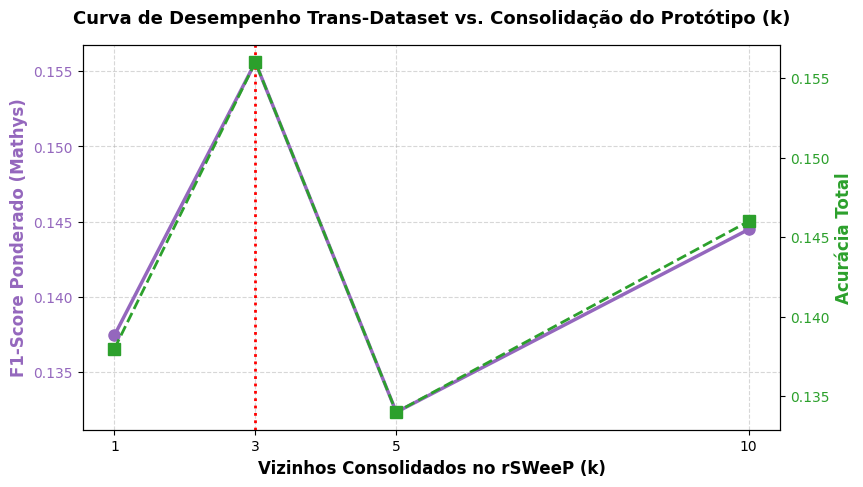


✓ Estudo Comparativo e Otimização Trans-Dataset Concluídos com Sucesso!


In [5]:
fig, ax1 = plt.subplots(figsize=(9, 5))
cor_f1 = 'tab:purple'
ax1.set_xlabel('Vizinhos Consolidados no rSWeeP (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1-Score Ponderado (Mathys)', color=cor_f1, fontsize=12, fontweight='bold')
linha1 = ax1.plot(df_k['k'], df_k['f1_weighted'], marker='o', markersize=8, linewidth=2.5, color=cor_f1, label='F1 Ponderado')
ax1.tick_params(axis='y', labelcolor=cor_f1)
ax1.set_xticks(df_k['k'])
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
cor_acc = 'tab:green'
ax2.set_ylabel('Acurácia Total', color=cor_acc, fontsize=12, fontweight='bold')
linha2 = ax2.plot(df_k['k'], df_k['acuracia'], marker='s', markersize=8, linestyle='--', linewidth=2, color=cor_acc, label='Acurácia')
ax2.tick_params(axis='y', labelcolor=cor_acc)

ax1.axvline(x=k_otimo, color='red', linestyle=':', linewidth=2, label=f'k* Ótimo ({k_otimo})')

plt.title('Curva de Desempenho Trans-Dataset vs. Consolidação do Protótipo (k)', fontsize=13, fontweight='bold', pad=15)
path_fig = os.path.join(OUT_RELATORIO, 'curva_otimizacao_k_mathys.png')
plt.savefig(path_fig, dpi=300, bbox_inches='tight')
print(f"Gráfico comparativo salvo em: {path_fig}")
plt.show()

print("\n[Sucesso] Estudo Comparativo e Otimização Trans-Dataset Concluídos com Sucesso!")